1. Set Up

In [1]:
import os
import cv2
import torch
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

2. File Config

In [2]:
VAL_DIR = r"D:\Skripsi_Raphaela\conv_lstm\dataset\dataset_split\val"
CLASSES = ['static', 'approaching']
SEQ_LENGTH = 15
IMG_SIZE = 112
BATCH_SIZE = 8

3. Dataset Loader

In [3]:
def get_folders_and_labels(base_dir):
    vids, labs = [], []
    for label_idx, label_name in enumerate(CLASSES):
        class_dir = os.path.join(base_dir, label_name)
        if not os.path.exists(class_dir): continue
            
        for obj_folder in os.listdir(class_dir):
            obj_path = os.path.join(class_dir, obj_folder)
            if not os.path.isdir(obj_path): continue
                
            vid_folders = [os.path.join(obj_path, d) for d in os.listdir(obj_path) if os.path.isdir(os.path.join(obj_path, d))]
            for f in vid_folders:
                if len([img for img in os.listdir(f) if img.lower().endswith('.jpg')]) >= SEQ_LENGTH:
                    vids.append(f)
                    labs.append(label_idx)
    return vids, labs

class SlidingWindowValidationDataset(Dataset):
    def __init__(self, folders, labels):
        self.sequences = []
        self.sequence_labels = []
        for folder, label in zip(folders, labels):
            images = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith('.jpg')])
            num_windows = len(images) - SEQ_LENGTH + 1
            if num_windows > 0:
                for i in range(num_windows):
                    self.sequences.append(images[i : i + SEQ_LENGTH])
                    self.sequence_labels.append(label)

    def __len__(self): return len(self.sequences)

    def __getitem__(self, idx):
        frames = []
        for p in self.sequences[idx]:
            img = cv2.imread(p)
            if img is None: img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            else: img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
            frames.append(img)
            
        frames = np.array(frames, dtype=np.float32) / 255.0
        frames = np.transpose(frames, (0, 3, 1, 2)) 
        return torch.tensor(frames), torch.tensor(self.sequence_labels[idx], dtype=torch.long)

# Initialize DataLoader
val_vids, val_labs = get_folders_and_labels(VAL_DIR)
val_dataset = SlidingWindowValidationDataset(val_vids, val_labs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

4. ONNX (INT8) Evaluation

Loading INT8 Model: D:\Skripsi_Raphaela\conv_lstm\program\convlstm_int8.onnx
Running Inference on 3447 Validation Sequences...


ONNX Evaluation: 100%|██████████| 431/431 [01:06<00:00,  6.44it/s]



CLASSIFICATION REPORT: CONVLSTM INT8
              precision    recall  f1-score   support

      static       0.78      0.54      0.64      1745
 approaching       0.64      0.84      0.73      1702

    accuracy                           0.69      3447
   macro avg       0.71      0.69      0.68      3447
weighted avg       0.71      0.69      0.68      3447



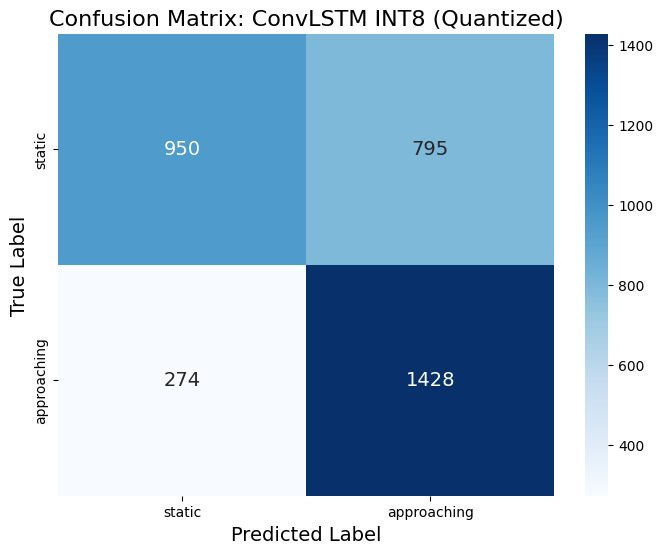

In [4]:
def evaluate_onnx_int8(onnx_path, dataloader):
    print(f"Loading INT8 Model: {onnx_path}")
    session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    input_name = session.get_inputs()[0].name

    all_preds, all_labels = [], []

    print(f"Running Inference on {len(val_dataset)} Validation Sequences...")
    for inputs, labels in tqdm(dataloader, desc="ONNX Evaluation"):
        # ONNX requires pure NumPy arrays
        input_np = inputs.numpy().astype(np.float32)
        
        outputs = session.run(None, {input_name: input_np})
        preds = np.argmax(outputs[0], axis=1)
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    # Generate Metrics
    print("\n" + "="*50)
    print("CLASSIFICATION REPORT: CONVLSTM INT8")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=CLASSES))

    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={"size": 14})
    plt.title('Confusion Matrix: ConvLSTM INT8 (Quantized)', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.savefig('confusion_matrix_int8.png', dpi=300)
    plt.show()

# Run the Evaluation
quantized_model_path = r"D:\Skripsi_Raphaela\conv_lstm\program\convlstm_int8.onnx"
evaluate_onnx_int8(quantized_model_path, val_loader)

In [5]:
def preprocess_frame(path):
    img = cv2.imread(path)
    if img is None: return None
    img = cv2.resize(img, (112, 112)) # Sesuai metadata ONNX
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # COBA: Hanya gunakan rescale 1/255 tanpa (img-0.5)/0.5
    # Banyak model ONNX hasil konversi sudah menghandle normalisasi secara internal
    img = img.astype(np.float32) / 255.0
    
    return np.transpose(img, (2, 0, 1))

In [6]:
def main():
    print(f"Memuat Model INT8: {MODEL_PATH}")
    session = ort.InferenceSession(MODEL_PATH, providers=['CPUExecutionProvider'])
    
    # Mengambil nama input secara dinamis (input_frames)
    input_name = session.get_inputs()[0].name
    
    total_seq = 0
    correct_seq = 0

    for label_name in CLASSES:
        class_dir = os.path.join(IMG_DIR, label_name)
        if not os.path.exists(class_dir):
            continue

        video_folders = [os.path.join(class_dir, d) for d in os.listdir(class_dir) 
                         if os.path.isdir(os.path.join(class_dir, d))]

        for video_folder in video_folders:
            image_files = sorted(glob(os.path.join(video_folder, "*.jpg")))
            if len(image_files) < SEQ_LENGTH:
                continue

            # Load frames
            processed_frames = []
            for f in image_files:
                p_frame = preprocess_frame(f)
                if p_frame is not None:
                    processed_frames.append(p_frame)

            if len(processed_frames) < SEQ_LENGTH:
                continue

            for i in range(len(processed_frames) - SEQ_LENGTH + 1):
                # Buat sequence shape: (1, 10, 3, 112, 112)
                seq_array = np.array(processed_frames[i : i + SEQ_LENGTH])
                input_data = np.expand_dims(seq_array, axis=0)

                # Jalankan Inferensi
                outputs = session.run(None, {input_name: input_data})
                logits = outputs[0][0]
                
                # Prediksi
                pred_idx = np.argmax(logits)
                predicted_label = CLASSES[pred_idx]

                total_seq += 1
                is_correct = (predicted_label == label_name)
                if is_correct:
                    correct_seq += 1
                
                print(f"Video: {os.path.basename(video_folder)} | GT: {label_name.upper():11} | Pred: {predicted_label.upper():11} | {'OK' if is_correct else 'FAIL'}")

    if total_seq > 0:
        print("\n" + "="*50)
        print(f"HASIL AKHIR EVALUASI")
        print(f"Total Sequences: {total_seq}")
        print(f"Benar: {correct_seq}")
        print(f"Akurasi: {(correct_seq/total_seq)*100:.2f}%")
        print("="*50)

if __name__ == "__main__":
    main()

NameError: name 'MODEL_PATH' is not defined

Loading Model: D:\Skripsi_Raphaela\conv_lstm\program\convlstm_int8.onnx

[INFO] Confusion Matrix disimpan sebagai 'confusion_matrix.png'

Classification Report:
              precision    recall  f1-score   support

 approaching       0.00      0.00      0.00       438
      static       0.50      1.00      0.66       431

    accuracy                           0.50       869
   macro avg       0.25      0.50      0.33       869
weighted avg       0.25      0.50      0.33       869

Average Precision (AP) for class approaching: 0.4976
Average Precision (AP) for class static: 0.4152

Final mAP: 0.4564


d:\Skripsi_Raphaela\rt_detr\program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Skripsi_Raphaela\rt_detr\program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Skripsi_Raphaela\rt_detr\program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

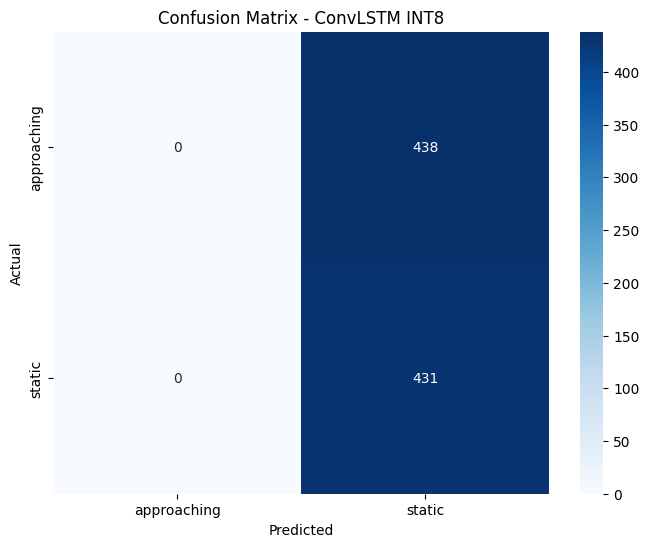

In [ ]:
import os
import cv2
import numpy as np
import onnxruntime as ort
from glob import glob
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
IMG_DIR = r"D:\Skripsi_Raphaela\conv_lstm\dataset\gambar"
MODEL_PATH = r"D:\Skripsi_Raphaela\conv_lstm\program\convlstm_int8.onnx"
IMG_SIZE = 112
SEQ_LENGTH = 10
CLASSES = ["approaching", "static"] # Index 0: approaching, Index 1: static

def preprocess_frame(path):
    img = cv2.imread(path)
    if img is None: return None
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Normalisasi Z-Score (sesuaikan jika training berbeda)
    img = img.astype(np.float32) / 255.0
    img = (img - 0.5) / 0.5 
    return np.transpose(img, (2, 0, 1))

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def main():
    print(f"Loading Model: {MODEL_PATH}")
    session = ort.InferenceSession(MODEL_PATH, providers=['CPUExecutionProvider'])
    input_name = session.get_inputs()[0].name
    
    y_true = []
    y_pred = []
    y_scores = [] # Untuk perhitungan mAP

    for label_idx, label_name in enumerate(CLASSES):
        class_dir = os.path.join(IMG_DIR, label_name)
        if not os.path.exists(class_dir): continue

        video_folders = [os.path.join(class_dir, d) for d in os.listdir(class_dir)]

        for video_folder in video_folders:
            image_files = sorted(glob(os.path.join(video_folder, "*.jpg")))
            if len(image_files) < SEQ_LENGTH: continue

            frames = [preprocess_frame(f) for f in image_files]
            frames = [f for f in frames if f is not None]

            for i in range(len(frames) - SEQ_LENGTH + 1):
                input_data = np.array(frames[i : i + SEQ_LENGTH])
                input_data = np.expand_dims(input_data, axis=0)

                outputs = session.run(None, {input_name: input_data})
                logits = outputs[0][0]
                
                probs = softmax(logits)
                pred_idx = np.argmax(probs)

                y_true.append(label_idx)
                y_pred.append(pred_idx)
                y_scores.append(probs) # Simpan probabilitas kedua kelas

    # --- EVALUASI ---
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)

    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - ConvLSTM INT8')
    plt.savefig('confusion_matrix.png')
    print("\n[INFO] Confusion Matrix disimpan sebagai 'confusion_matrix.png'")

    # 2. Classification Report (Precision, Recall, F1)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    # 3. Mean Average Precision (mAP)
    # Untuk mAP, kita hitung AP per kelas lalu dirata-rata
    aps = []
    for i in range(len(CLASSES)):
        # Buat label biner untuk kelas i
        true_binary = (y_true == i).astype(int)
        score_binary = y_scores[:, i]
        ap = average_precision_score(true_binary, score_binary)
        aps.append(ap)
        print(f"Average Precision (AP) for class {CLASSES[i]}: {ap:.4f}")

    mAP = np.mean(aps)
    print(f"\nFinal mAP: {mAP:.4f}")

if __name__ == "__main__":
    main()